### Наивный байесовский классификатор

#### Цель работы

Научиться применять модели наивного байесовского классификатора с использованием библиотеки sklearn для решения задач машинного обучения.

#### Содержание работы

1. Загрузите датасет _breast\_cancer_ из библиотеки _sklearn_.
2. Выведите в виде гистограммы распределения непрерывных атрибутов в этом наборе данных.
3. Постройте модель наивного байесовского классификатора на первых двух столбцах и оцените ее качество.
4. Постройте ту же модель на полном датасете и сравните ее качество с первой.
5. Отберите признаки, соответствующие выбранному модельному виду распределения. Постройте модель на выбранных признаках и сравните ее с предыдущей.

#### Методические указания

Загрузим встроенный в библиотеку _sklearn_ датасет с данными о диагностике рака груди:

In [271]:
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, r2_score, mean_squared_error
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB

In [272]:
data = datasets.load_breast_cancer()

In [273]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

Если вы встречаете этот набор данных впервые, самостоятельно выведите его описание и познакомьтесь с его структурой. Мы же выделим целевую переменную и входные атрибуты. Для целей визуализации выберем первые два столбца:

In [274]:
X = data.data[:,:2]
y = data.target

Для работы байесовского классификатора важно понимать, какие значения может принимать целевая переменная. Поэтому выведем информацию о количестве разных значений целевой переменной в получившейся обучающей выборке:

In [275]:
df = pd.DataFrame(data.data[:,:2], columns=data.feature_names[:2])
df['target'] = data.target
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

Теперь можно визуализировать получившееся распределение точек:

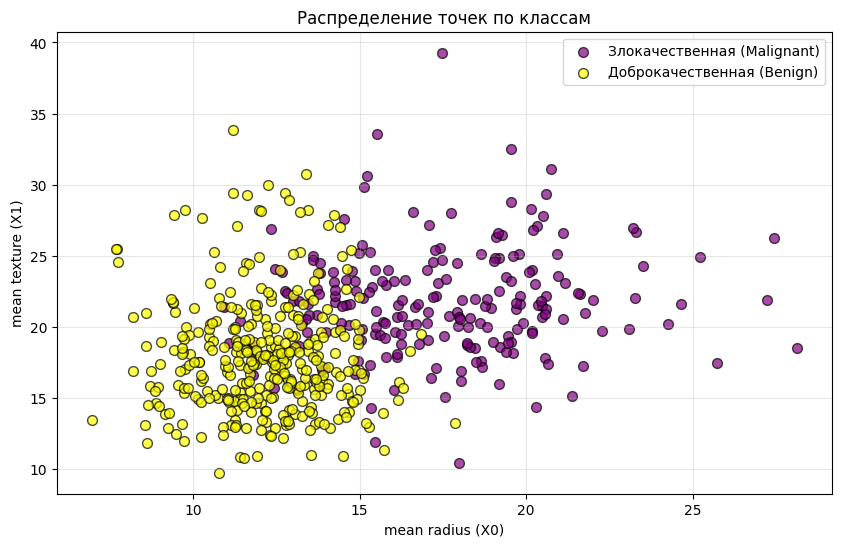

In [276]:
# Визуализация распределения точек. первые два признака
plt.figure(figsize=(10, 6))

colors = {0: 'purple', 1: 'yellow'}
labels = {0: 'Злокачественная (Malignant)', 1: 'Доброкачественная (Benign)'}

for target_class in [0, 1]:
    mask = y == target_class
    plt.scatter(X[mask, 0], X[mask, 1], 
                c=colors[target_class], label=labels[target_class], 
                alpha=0.7, edgecolors='black', s=50)

plt.xlabel(f"{data.feature_names[0]} (X0)")
plt.ylabel(f"{data.feature_names[1]} (X1)")
plt.title('Распределение точек по классам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Мы видим, что данные являются линейно неразделимыми. Да и вообще, классы довольно сильно перемешаны. Посмотрим, что может сделать классификатор на основе формуля Байеса.

Для создания модели наивного байесовского классификатора необходимо выбрать то, каким именно распределением модель будет аппроксимировать функцию плотности вероятности непрерывных переменных. Так как обе наши входные переменные как раз непрерывные, лучш евывести форму их распределения, чтобы понять, на какое известное статистическое распределение она похожа. Для этого воспользуемся инструментом построения гистограмм библиотеки matplotlib. Построим сразу обе гистограммы (для двух атрибутов) на одном графике в подобластях:

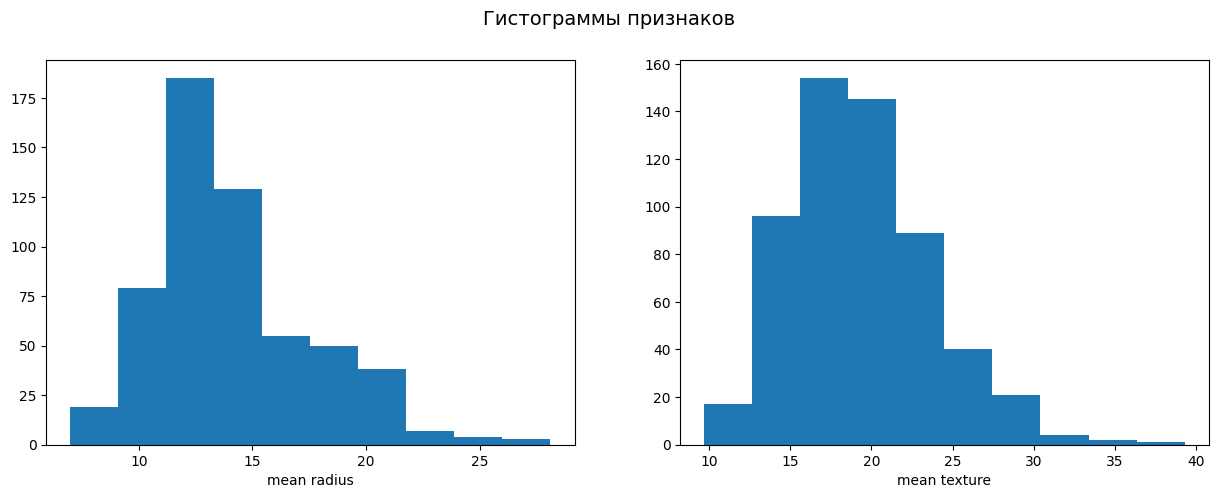

In [277]:
plt.figure(figsize=(15, 5))
for i in range(2):    
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

Из графиков видно, что форма распределения обоих признаков напоминает нормальное. Можно принять гипотезу о нормальности распределения наших признаков и использовать модель наивного Байеса с гауссовой аппроксимацией. Для создания можели инстанцируем соответствующих класс:

In [278]:
gaussian_nb = GaussianNB()

Обучим модель на имеющихся у нас данных:

In [279]:
gaussian_nb.fit(X, y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Теперь визуализируем границу принятия решения и соответствующие области классификации:

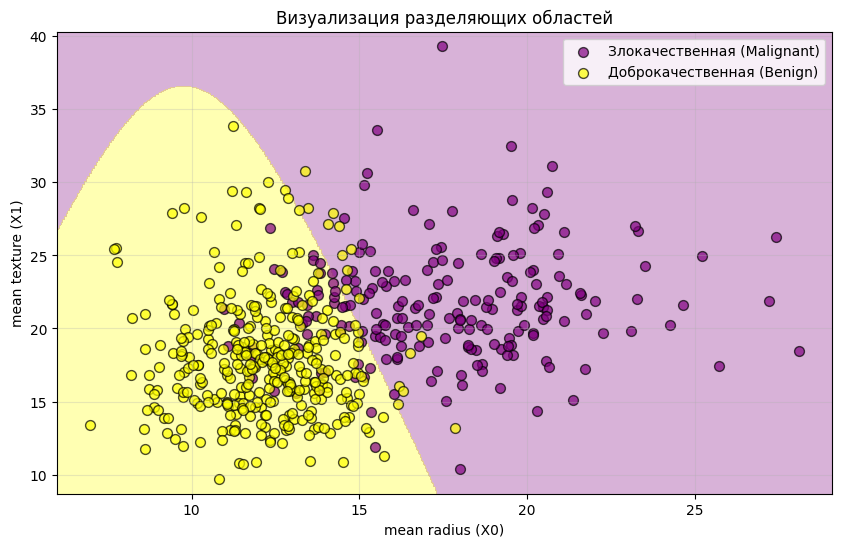

In [280]:
# Создаем сетку точек для построения границы
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Предсказываем класс для каждой точки сетки
Z = gaussian_nb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=['purple', 'yellow'])

# Отображение точек данных
colors = {0: 'purple', 1: 'yellow'}
labels = {0: 'Злокачественная (Malignant)', 1: 'Доброкачественная (Benign)'}
for target_class in [0, 1]:
    mask = y == target_class
    plt.scatter(X[mask, 0], X[mask, 1], 
                c=colors[target_class], label=labels[target_class], 
                alpha=0.7, edgecolors='black', s=50)

plt.xlabel(f"{data.feature_names[0]} (X0)")
plt.ylabel(f"{data.feature_names[1]} (X1)")
plt.title('Визуализация разделяющих областей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Для более точной оценки эффективности модели посчитаем метрики. Для этого рассчитаем теоретические значения целевой переменной для объектов обучающей выборки:

In [281]:
y_pred = gaussian_nb.predict(X)

Тпереь выведем значения метрик. Мы можем здесь использовать какие угодно метрики эффективности моделей классификации, но для первого анализа будет достаточно вывести, например, матрицу классификации, точность и метрику F1:

In [282]:
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[164  48]
 [ 17 340]]
Accuracy=  0.8857644991212654
F1_score=  0.912751677852349


Мы получили, что модель правильно классифицирует 88,6% объектов обучающей выборки. Это при том, что мы обучались только на первых двух столбцах.

Естественно, нужно проверить, как наша модель будет работать при использовании всех данных, имеющихся в исходном датасете. Выделим целевую переменную и атрибуты снова:

In [283]:
X = data.data
y = data.target
X.shape, y.shape

((569, 30), (569,))

Обучим модель на всех данных и сразу выведем те же самые метрики:

In [284]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


У нас получилась точность примерно 94,2%. Это значительно лучше, чем у первой модели, что естественно, так как мы используем гораздо больше информации об объектах обучающей выборки.

Так как использование байесовской модели тесно связано с аппроксимацией непрерывных расрпеделений, давайте выведем гистограммы всех атрибутов, которые мы использовали во второй модели:

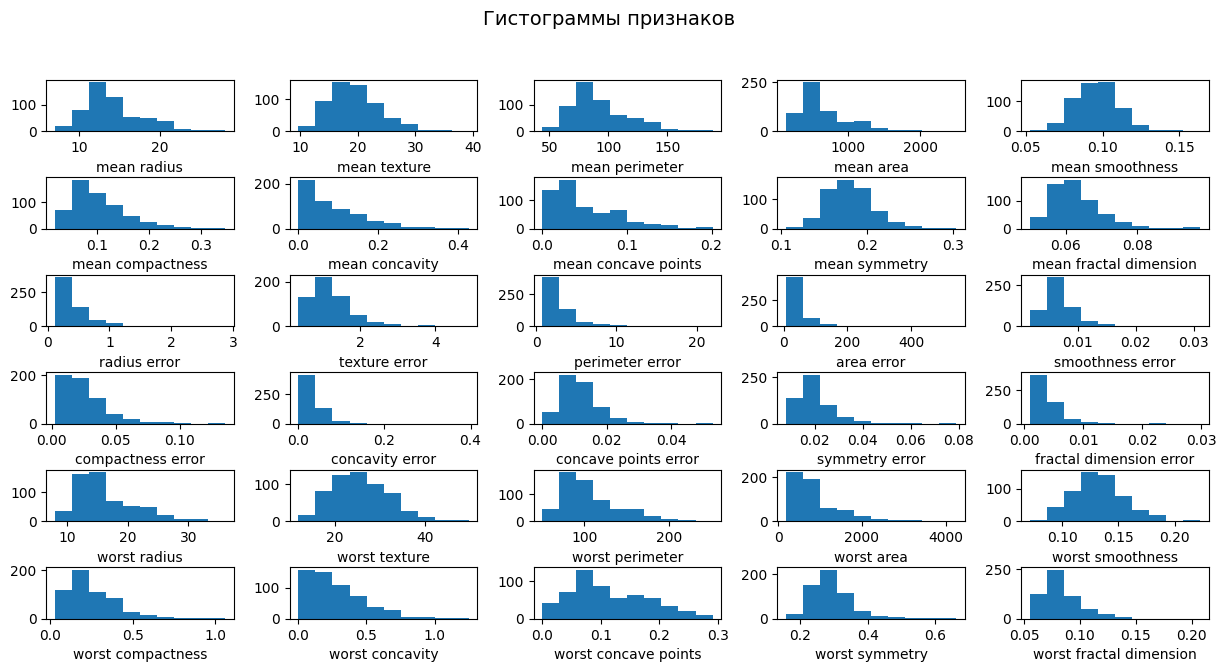

In [285]:
f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X[:, i])
    
    plt.xlabel(data.feature_names[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)    
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

Из данного графика видно, что у большинства признаков распределение и правда напоминает нормальное. Но некоторые распределения совсем на него не похожи. Давайте удалим из набора данных те признаки, которые по своему виду распределения сильно отличаются от нормального:

In [286]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df = df.drop(['mean concavity','radius error', 
              'perimeter error', 'area error', 
              'compactness error', 'concavity error',
              'fractal dimension error', 'worst area', 
              'worst concavity'], axis=1)

X_selected = df.drop('target', axis=1).values
y_selected = df['target'].values

Обучим модель на оставшихся данных и оценим ее качество:

In [287]:
gaussian_nb.fit(X_selected, y_selected)
y_pred = gaussian_nb.predict(X_selected)

print(confusion_matrix(y_selected, y_pred))
print('Accuracy = ', accuracy_score(y_selected, y_pred))
print('F1_score = ', f1_score(y_selected, y_pred))

[[196  16]
 [ 15 342]]
Accuracy =  0.945518453427065
F1_score =  0.9566433566433566


Мы получили, что такая урезанная модель дает даже чуть большую точность - около 94,6%. Это парадоксальный результат, так как мы использовали меньше информации. Но такое увеличение точности произошло потому, что мы исключили признаки, которые сильно не соответствуют данному виду модели. Таким образом можно сделать вывод, что такие принаки, будучи введенными в модель не способны добавить точности предсказания, а скорее "запутывают" классификатор.

### Контрольные вопросы

**1. Какие условия должны выполняться в данных, чтобы можно было применять наивную байесовскую модель?**  
- Признаки должны быть независимы друг от друга при условии класса (наивное предположение).  
- Для каждого класса распределение признаков должно соответствовать выбранной параметрической модели (например, нормальное для GaussianNB).  
- Данные должны быть представительными для оценки параметров распределений.  
- Отсутствие мультиколлинеарности между признаками.

**2. Какие виды непрерывных распределений существуют и наиболее распространены?**  
- Нормальное (Гауссово) – симметричное, колоколообразное.  
- Равномерное – все значения равновероятны.  
- Экспоненциальное – моделирует время между событиями.  
- Гамма-распределение – обобщение экспоненциального.  
- Бета-распределение – на отрезке [0,1].  
- Логнормальное – логарифм переменной распределён нормально.  
- Распределение Лапласа (двойное экспоненциальное).

**3. Как определить вид распределения численной переменной в датасете?**  
- Визуально: построить гистограмму, ящик с усами (box plot), график плотности (KDE).  
- Количественно: тесты на нормальность (Шапиро-Уилка, Колмогорова-Смирнова, Андерсона-Дарлинга).  
- Сравнить эмпирическое распределение с теоретическим с помощью Q-Q графика.  
- Рассчитать числовые характеристики: асимметрию (skewness) и эксцесс (kurtosis).

**4. Как наивная байесовская модель работает с категориальными признаками?**  
Используются специальные варианты классификатора:  
- **MultinomialNB** – для дискретных признаков, подходит для подсчёта частот (например, количество слов в тексте).  
- **BernoulliNB** – для бинарных признаков (0/1), например, наличие/отсутствие слова.  
- **CategoricalNB** – для категориальных признаков с произвольным числом категорий.  
Оценка вероятностей производится по частотам встречаемости категорий внутри каждого класса с использованием сглаживания (Лапласа).

**5. Зачем при применении наивного байесовского классификатора может понадобится анализировать форму эмпирического распределения признаков?**  
Чтобы правильно выбрать вид модели:  
- Если признак распределён нормально – используем GaussianNB.  
- Если признак дискретный/бинарный – MultinomialNB или BernoulliNB.  
- Если распределение далеко от нормального, использование GaussianNB даст неверные оценки вероятностей и снизит качество.  
Анализ распределения помогает также решить, нужно ли преобразовывать признаки (например, логарифмировать, нормализовать) перед подачей в модель.

**6. В чем особенность модели категориального наивного Байеса?**  
CategoricalNB предназначен для работы с категориальными (номинальными) признаками, которые могут принимать одно из конечного множества значений (например, цвет: красный/синий/зелёный). Особенности:  
- Не требует кодирования признаков в бинарный вид (как BernoulliNB) или в частоты (как MultinomialNB).  
- Оценивает вероятность каждого значения признака отдельно для каждого класса.  
- Использует сглаживание Лапласа (альфа-параметр) для обработки ранее не встреченных категорий.  
- Признаки могут быть как целыми числами (индексы категорий), так и строковыми (после кодирования).